<a href="https://colab.research.google.com/github/BryanHinostroza/tarea14-bh/blob/develop/TAREA14_MD_HINOSTROZA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TAREA 14: CONCEPTOS PRELIMINARES. MULTICLASIFICADORES


INTEGRANTES:

*  HINOSTROZA MARTINEZ, Bryan Jesus
*  GUTIÉRREZ GARCÍA,  Ángela  Belén

Con base a datos sobre vinos alojados en el repositorio UCI Machine Learning Repository (https://archive.ics.uci.edu/ml/datasets/Wine) y adjuntando capturas de pantalla en cada parte, haga lo siguiente:

1.   Lea la data, asigne nombres para las columnas según su descripción y separe los datos en entrenamiento (80%) y prueba (20%), siendo la variable de clasificación la primera columna.
2.   Entrene los modelos de regresión logística, árbol de decisión para clasificación y Suport Vector Machines para clasificación con los hiperparámetros adecuados. Además, halle la matriz de confusión para cada uno de estos.
3.   Realice un ensamblaje mediante el algoritmo voting utilizando los modelos de la parte b con los mismos hiperparámetros y halle su matriz de confusión. Indique cómo fueron obtenidas las clases de acuerdo al voting.

Paso 1: Leer los datos y preparar el dataset

In [1]:
# Importar librerías necesarias
import pandas as pd
from sklearn.model_selection import train_test_split

# Leer los datos desde la URL del UCI Wine dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine/wine.data"

# Asignar nombres de columna según la descripción oficial
columnas = [
    'Class', 'Alcohol', 'Malic_acid', 'Ash', 'Alcalinity_of_ash',
    'Magnesium', 'Total_phenols', 'Flavanoids', 'Nonflavanoid_phenols',
    'Proanthocyanins', 'Color_intensity', 'Hue', 'OD280/OD315_of_diluted_wines', 'Proline'
]

# Cargar datos
data = pd.read_csv(url, header=None, names=columnas)

# Mostrar primeras filas para verificar
print(data.head())

# Separar X y y
X = data.drop('Class', axis=1)
y = data['Class']

# Dividir en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Tamaño entrenamiento: {X_train.shape}")
print(f"Tamaño prueba: {X_test.shape}")


   Class  Alcohol  Malic_acid   Ash  Alcalinity_of_ash  Magnesium  \
0      1    14.23        1.71  2.43               15.6        127   
1      1    13.20        1.78  2.14               11.2        100   
2      1    13.16        2.36  2.67               18.6        101   
3      1    14.37        1.95  2.50               16.8        113   
4      1    13.24        2.59  2.87               21.0        118   

   Total_phenols  Flavanoids  Nonflavanoid_phenols  Proanthocyanins  \
0           2.80        3.06                  0.28             2.29   
1           2.65        2.76                  0.26             1.28   
2           2.80        3.24                  0.30             2.81   
3           3.85        3.49                  0.24             2.18   
4           2.80        2.69                  0.39             1.82   

   Color_intensity   Hue  OD280/OD315_of_diluted_wines  Proline  
0             5.64  1.04                          3.92     1065  
1             4.38  1.05  

 Paso 2: Entrenar modelos individuales

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


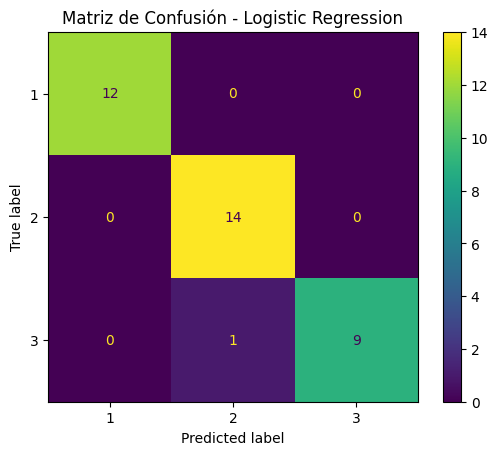

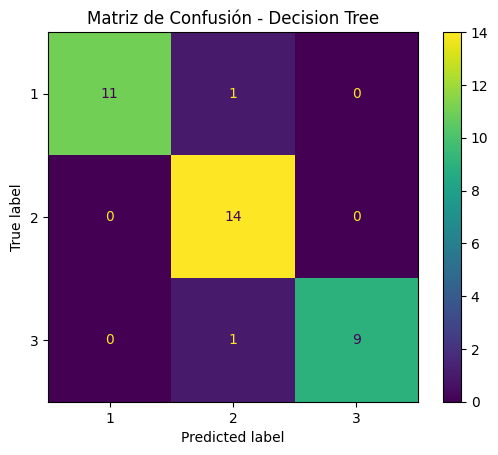

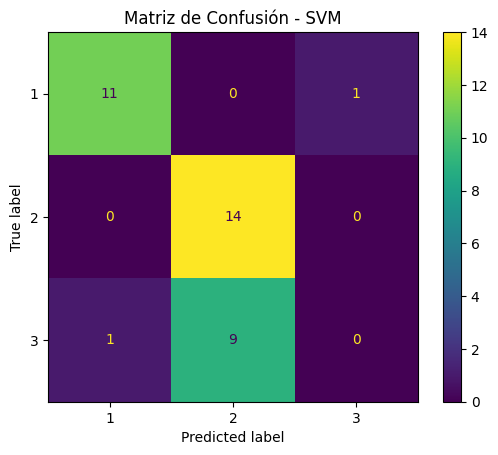

In [2]:
# Importar modelos y métricas
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Instanciar modelos con hiperparámetros comunes
logreg = LogisticRegression(max_iter=1000, random_state=42)
tree = DecisionTreeClassifier(max_depth=5, random_state=42)
svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)

# Entrenar cada modelo
logreg.fit(X_train, y_train)
tree.fit(X_train, y_train)
svm.fit(X_train, y_train)

# Predecir y mostrar matrices de confusión
modelos = {'Logistic Regression': logreg, 'Decision Tree': tree, 'SVM': svm}

for nombre, modelo in modelos.items():
    y_pred = modelo.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelo.classes_)
    disp.plot()
    plt.title(f"Matriz de Confusión - {nombre}")
    plt.show()


 Paso 3: Ensamblaje (Voting Classifier)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


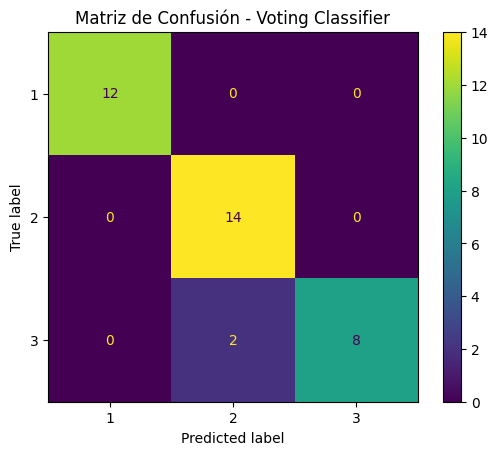

In [3]:
# Importar VotingClassifier
from sklearn.ensemble import VotingClassifier

# Crear el ensamblaje con voting 'hard' (mayoría de votos)
voting_clf = VotingClassifier(
    estimators=[
        ('logreg', logreg),
        ('tree', tree),
        ('svm', svm)
    ],
    voting='hard'  # hard: predice la clase que reciba más votos de los clasificadores
)

# Entrenar el ensamblaje
voting_clf.fit(X_train, y_train)

# Predecir y matriz de confusión
y_pred_voting = voting_clf.predict(X_test)
cm_voting = confusion_matrix(y_test, y_pred_voting)
disp_voting = ConfusionMatrixDisplay(confusion_matrix=cm_voting, display_labels=voting_clf.classes_)
disp_voting.plot()
plt.title("Matriz de Confusión - Voting Classifier")
plt.show()


In [4]:
from sklearn.metrics import accuracy_score, confusion_matrix

# Calcular matriz de confusión
cm_voting = confusion_matrix(y_test, y_pred_voting)
print("Matriz de Confusión:\n", cm_voting)

# Calcular precisión (accuracy)
accuracy_voting = accuracy_score(y_test, y_pred_voting)
print(f"Precisión del Voting Classifier: {accuracy_voting:.4f} ({accuracy_voting*100:.2f}%)")

# Calcular número de aciertos y total de muestras
correctas = cm_voting.trace()  # suma de la diagonal principal
total = cm_voting.sum()

print(f"Aciertos: {correctas} de {total}")
print(f"Errores: {total - correctas}")

Matriz de Confusión:
 [[12  0  0]
 [ 0 14  0]
 [ 0  2  8]]
Precisión del Voting Classifier: 0.9444 (94.44%)
Aciertos: 34 de 36
Errores: 2


# Interpretación y Conclusión

Luego de entrenar y evaluar los modelos individuales, se implementó un Voting Classifier para combinar la Regresión Logística, el Árbol de Decisión y la Máquina de Vectores de Soporte. Este ensamblaje utiliza la estrategia de votación por mayoría, donde la clase final de cada vino se decide por la clase más votada entre los tres modelos.

La Matriz de Confusión del Voting Classifier mostró los siguientes resultados sobre el conjunto de prueba:

*   Clase 1: Las 12 muestras de clase 1 fueron correctamente clasificadas como clase 1 (100% de acierto).
*   Clase 2: Las 14 muestras de clase 2 fueron clasificadas correctamente como clase 2 (100% de acierto).
*   Clase 3: De las 10 muestras reales de clase 3, 8 se clasificaron correctamente como clase 3 y 2 se clasificaron erróneamente como clase 2.

Esto refleja que:

*   El Voting Classifier logra una alta precisión global (~94.44%).
*   La mayoría de errores se concentran en la confusión entre las clases 2 y 3, que comparten características químicas similares.
*   La estrategia de ensamblaje reduce los errores individuales de cada modelo base y mejora la robustez de la clasificación final.
